In [9]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [2]:
adata_subset = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/combined_epi_adata_clustered_(30,27)_(0.5,1)_8_5_25.h5ad")

In [30]:
adata_subset.obs["sample"]

CellID
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGGCTCCCGATCTx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGTACACTTTAGGx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGCTGTGCCTGACx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGAACGTCTCGGGTx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGAAGTCACTTCCx    m5
                                                                           ..
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGGTTAGAGGCTGTx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGATCCACTGGACCx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGACTAGTTGGACGx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGTTGGTGCGGCTTx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGGAGTCGACGAGAx     p4
Name: sample, Length: 4655, dtype: category
Categories (5, object): ['m5', 'p5_1', 'p5_2', 'm4', 'p4']

In [17]:
adata_subset.X.min(),adata_subset.X.max()

(0.0, 8.8132925)

In [19]:
glasbey_clean_24 = [
    "#E41A1C",  # Red
    "#377EB8",  # Blue
    "#4DAF4A",  # Green
    "#984EA3",  # Purple
    "#FF7F00",  # Orange
    "#FFFF33",  # Yellow
    "#A65628",  # Brown
    "#F781BF",  # Pink
    "#999999",  # Gray
    "#66C2A5",  # Teal
    "#FC8D62",  # Coral
    "#8DA0CB",  # Muted blue
    "#E78AC3",  # Light pink
    "#A6D854",  # Lime
    "#FFD92F",  # Yellow-orange
    "#E5C494",  # Tan
    "#B3B3B3",  # Light gray
    "#1B9E77",  # Deep teal
    "#D95F02",  # Burnt orange
    "#7570B3",  # Muted violet
    "#E7298A",  # Vivid pink
    "#66A61E",  # Olive green
    "#E6AB02",  # Goldenrod
    "#A6761D"   # Rich brown
]

In [37]:
genes = ["calb2a", "dlb", "postnb"]
samples = ["m5", "p5_2","m4", "p4"]

In [45]:
sample_palette = dict(zip(samples, glasbey_clean_24[:len(samples)]))

In [49]:
genes = ["calb2a", "dlb", "postnb"]
samples = ["m5", "p5_1","m4", "p4"]
sample_palette = dict(zip(samples, glasbey_clean_24[:len(samples)]))

In [13]:
adata.obs["sample"]

CellID
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGGCTCCCGATCTx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGTACACTTTAGGx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGCTGTGCCTGACx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGAACGTCTCGGGTx    m5
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGAAGTCACTTCCx    m5
                                                                           ..
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGGTTAGAGGCTGTx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGATCCACTGGACCx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGACTAGTTGGACGx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGTTGGTGCGGCTTx     p4
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGGAGTCGACGAGAx     p4
Name: sample, Length: 3561, dtype: category
Categories (4, object): ['m5', 'p5_1', 'm4', 'p4']

In [14]:
# sanity checks
assert adata.n_obs == len(samples_renamed), "labels length mismatch"
missing_genes = [g for g in genes if g not in adata.var_names]
assert not missing_genes, f"Gene(s) not in var_names: {missing_genes}"
print("cells:", adata.n_obs, "samples:", samples_renamed.nunique(), samples_renamed.unique())


cells: 3561 samples: 4 ['CB345 Control' 'CB345 Eda OE' 'CB4 Control' 'CB4 Eda OE']


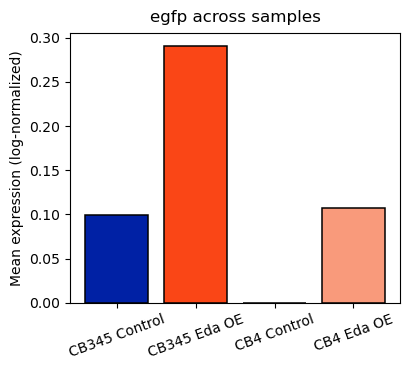

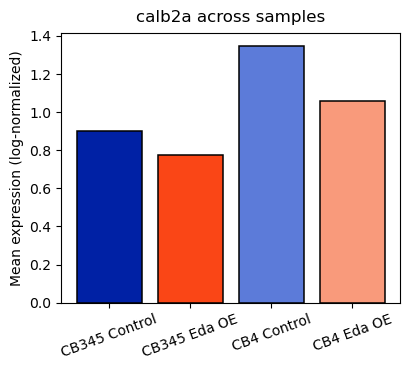

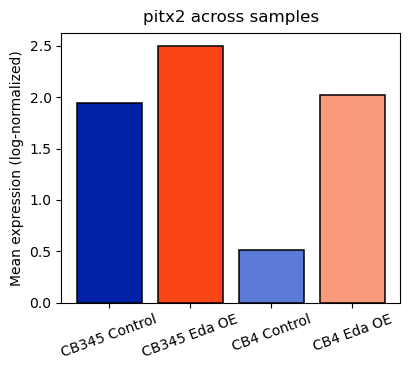

In [18]:
import matplotlib.pyplot as plt
from scipy.stats import sem

# ---- inputs you set ----
keep = {"m5", "p5_1", "m4", "p4"}   # whitelist
mask = adata_subset.obs["sample"].astype(str).isin(keep)
adata = adata_subset[mask].copy()

genes = ["egfp","calb2a","pitx2"]         # whatever list you want to show
# map old sample IDs -> poster-friendly labels
rename = {
    "m5":  "CB345 Control",
    "p5_1":  "CB345 Eda OE",
    "m4":  "CB4 Control",
    "p4":  "CB4 Eda OE",
}
# order on the poster
samples_order = ["CB345 Control","CB345 Eda OE","CB4 Control","CB4 Eda OE"]

# UF-ish palette: orange = OE, blue = Control (lighter vs darker by region)
sample_palette = {
    "CB345 Eda OE":   "#FA4616",  # UF orange (dark)
    "CB345 Control":  "#0021A5",  # UF blue (dark)
    "CB4 Eda OE":     "#F99A7B",  # lighter orange
    "CB4 Control":    "#5C7BD9",  # lighter blue
}

# ---- helper: get one gene vector as 1D dense safely ----
def gene_expr(adata, gene):
    Xg = adata[:, gene].X
    # works for sparse or dense
    return (Xg.A if hasattr(Xg, "A") else np.asarray(Xg)).ravel()

# ---- build one obs-side series for sample labels (renamed) ----
samples_renamed = adata.obs["sample"].astype(str).map(rename)
if samples_renamed.isna().any():
    missing = sorted(set(adata.obs["sample"].astype(str)) - set(rename))
    raise ValueError(f"Missing rename mapping for: {missing}")

# ---- plotting loop (no giant dense DataFrame needed) ----
def gene_expr_array(ad, gene):
    Xg = ad[:, gene].X
    Xg = Xg.toarray() if hasattr(Xg, "toarray") else np.asarray(Xg)
    arr = np.asarray(Xg).reshape(ad.n_obs, -1)  # force (n_obs, 1)
    assert arr.shape[1] == 1, f"{gene} slice wrong shape {arr.shape}"
    return arr[:, 0]

# sanity checks BEFORE loop
assert adata.n_obs == len(samples_renamed), "labels length mismatch pre-loop"
missing_genes = [g for g in genes if g not in adata.var_names]
assert not missing_genes, f"Missing genes in var_names: {missing_genes}"

for gene in genes:
    y = gene_expr_array(adata, gene)
    labels = samples_renamed.values
    assert y.shape == (adata.n_obs,), f"{gene}: y shape {y.shape} != ({adata.n_obs},)"
    assert labels.shape == (adata.n_obs,), f"labels shape {labels.shape} != ({adata.n_obs},)"

    # build via explicit index to avoid any weird alignment
    idx = np.arange(adata.n_obs)
    df = pd.DataFrame(index=idx)
    df["sample"] = labels
    df["expr"] = y

    # if you want to be extra safe about dropped labels:
    df = df.dropna(subset=["sample"])

    stat = (
        df.groupby("sample", observed=True)["expr"]
          .agg(mean="mean",
               se=lambda x: sem(x, ddof=1) if len(x) > 1 else np.nan,
               n="count")
          .reindex(samples_order)
          .reset_index()
    )

    colors = [sample_palette.get(s, "#888888") for s in stat["sample"]]

    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    ax.bar(stat["sample"], stat["mean"], capsize=4, #yerr=stat["se"],
           color=colors, edgecolor="black", linewidth=1.1)
    ax.set_ylabel("Mean expression (log-normalized)")
    ax.set_xlabel("")
    ax.set_title(f"{gene} across samples", pad=8)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", rotation=20)

    #for xi, (m, n) in enumerate(zip(stat["mean"], stat["n"])):
        #ax.text(xi, m, f" n={int(n)}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{gene}_barplot_by_sample_no_errorbar.pdf", dpi=300)
    plt.show()

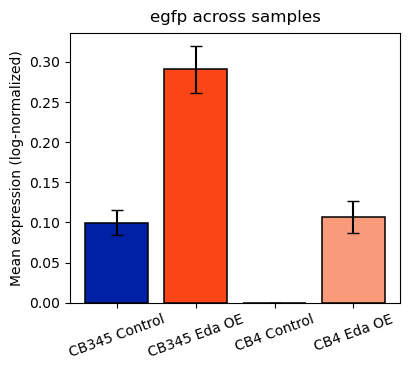

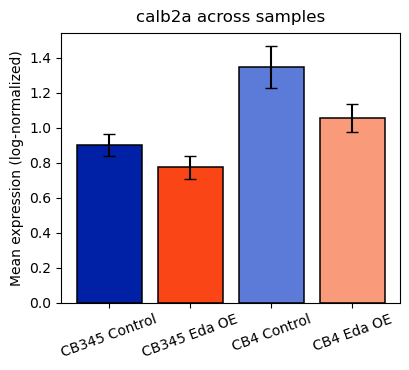

In [20]:
import matplotlib.pyplot as plt
from scipy.stats import sem

# ---- inputs you set ----
keep = {"m5", "p5_1", "m4", "p4"}   # whitelist
mask = adata_subset.obs["sample"].astype(str).isin(keep)
adata = adata_subset[mask].copy()

genes = ["egfp","calb2a"]         # whatever list you want to show
# map old sample IDs -> poster-friendly labels
rename = {
    "m5":  "CB345 Control",
    "p5_1":  "CB345 Eda OE",
    "m4":  "CB4 Control",
    "p4":  "CB4 Eda OE",
}
# order on the poster
samples_order = ["CB345 Control","CB345 Eda OE","CB4 Control","CB4 Eda OE"]

# UF-ish palette: orange = OE, blue = Control (lighter vs darker by region)
sample_palette = {
    "CB345 Eda OE":   "#FA4616",  # UF orange (dark)
    "CB345 Control":  "#0021A5",  # UF blue (dark)
    "CB4 Eda OE":     "#F99A7B",  # lighter orange
    "CB4 Control":    "#5C7BD9",  # lighter blue
}

# ---- helper: get one gene vector as 1D dense safely ----
def gene_expr(adata, gene):
    Xg = adata[:, gene].X
    # works for sparse or dense
    return (Xg.A if hasattr(Xg, "A") else np.asarray(Xg)).ravel()

# ---- build one obs-side series for sample labels (renamed) ----
samples_renamed = adata.obs["sample"].astype(str).map(rename)
if samples_renamed.isna().any():
    missing = sorted(set(adata.obs["sample"].astype(str)) - set(rename))
    raise ValueError(f"Missing rename mapping for: {missing}")

# ---- plotting loop (no giant dense DataFrame needed) ----
def gene_expr_array(ad, gene):
    Xg = ad[:, gene].X
    Xg = Xg.toarray() if hasattr(Xg, "toarray") else np.asarray(Xg)
    arr = np.asarray(Xg).reshape(ad.n_obs, -1)  # force (n_obs, 1)
    assert arr.shape[1] == 1, f"{gene} slice wrong shape {arr.shape}"
    return arr[:, 0]

# sanity checks BEFORE loop
assert adata.n_obs == len(samples_renamed), "labels length mismatch pre-loop"
missing_genes = [g for g in genes if g not in adata.var_names]
assert not missing_genes, f"Missing genes in var_names: {missing_genes}"

for gene in genes:
    y = gene_expr_array(adata, gene)
    labels = samples_renamed.values
    assert y.shape == (adata.n_obs,), f"{gene}: y shape {y.shape} != ({adata.n_obs},)"
    assert labels.shape == (adata.n_obs,), f"labels shape {labels.shape} != ({adata.n_obs},)"

    # build via explicit index to avoid any weird alignment
    idx = np.arange(adata.n_obs)
    df = pd.DataFrame(index=idx)
    df["sample"] = labels
    df["expr"] = y

    # if you want to be extra safe about dropped labels:
    df = df.dropna(subset=["sample"])

    stat = (
        df.groupby("sample", observed=True)["expr"]
          .agg(mean="mean",
               se=lambda x: sem(x, ddof=1) if len(x) > 1 else np.nan,
               n="count")
          .reindex(samples_order)
          .reset_index()
    )

    colors = [sample_palette.get(s, "#888888") for s in stat["sample"]]

    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    ax.bar(stat["sample"], stat["mean"], capsize=4, yerr=stat["se"],
           color=colors, edgecolor="black", linewidth=1.1)
    ax.set_ylabel("Mean expression (log-normalized)")
    ax.set_xlabel("")
    ax.set_title(f"{gene} across samples", pad=8)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", rotation=20)

    #for xi, (m, n) in enumerate(zip(stat["mean"], stat["n"])):
        #ax.text(xi, m, f" n={int(n)}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{gene}_barplot_by_sample_.pdf", dpi=300)
    plt.show()

/scratch/local/9436980/ipykernel_84879/2327487824.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


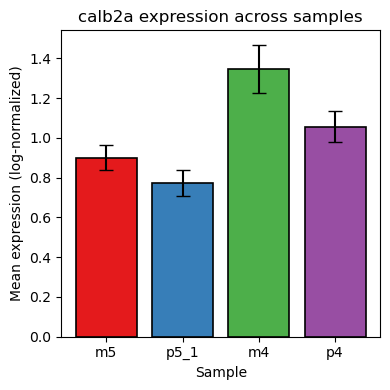

/scratch/local/9436980/ipykernel_84879/2327487824.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


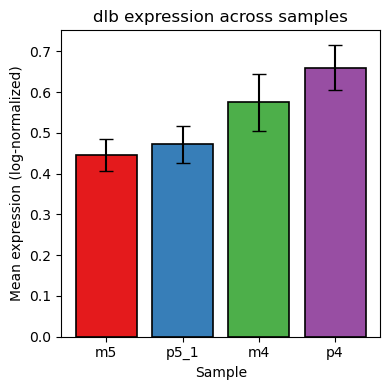

/scratch/local/9436980/ipykernel_84879/2327487824.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


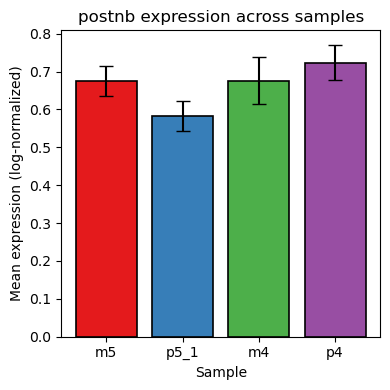

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem  # standard error of the mean

# --- Parameters ---
adata = adata_subset  # assuming this is your subset

# Convert to dense dataframe
# Convert expression matrix to DataFrame
df = pd.DataFrame(adata.X.toarray(), columns=adata.var_names)
df["sample"] = adata.obs["sample"].values

# Loop through genes
for gene in genes:
    # Compute mean and SE per sample
    plot_df = (
        df.groupby("sample")[gene]
        .agg(mean="mean", se=sem)
        .reindex(samples)  # maintain order
        .reset_index()
    )
    colors = [sample_palette[s] for s in plot_df["sample"]]
    # Plot using matplotlib
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(plot_df["sample"], plot_df["mean"], yerr=plot_df["se"],
           capsize=5, color=colors, edgecolor="black", linewidth=1.2)

    ax.set_ylabel("Mean expression (log-normalized)")
    ax.set_xlabel("Sample")
    ax.set_title(f"{gene} expression across samples")
    ax.set_ylim(bottom=0)  # avoid negative y-axis
    plt.tight_layout()
    #plt.savefig(f"{gene}_barplot_by_sample.pdf", dpi=300)
    plt.show()

/scratch/local/9436980/ipykernel_84879/1384959874.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


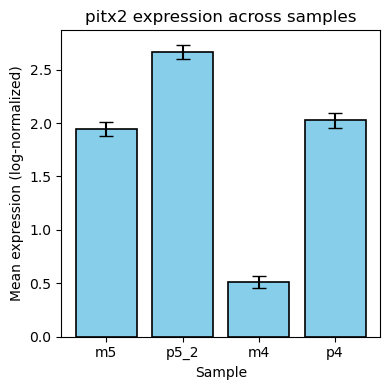

/scratch/local/9436980/ipykernel_84879/1384959874.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


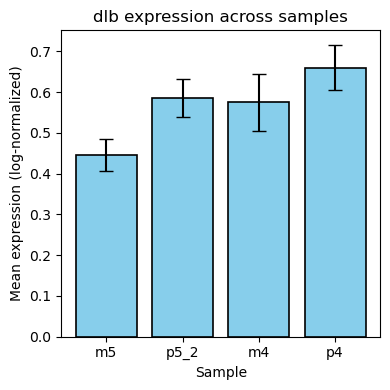

/scratch/local/9436980/ipykernel_84879/1384959874.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sample")[gene]


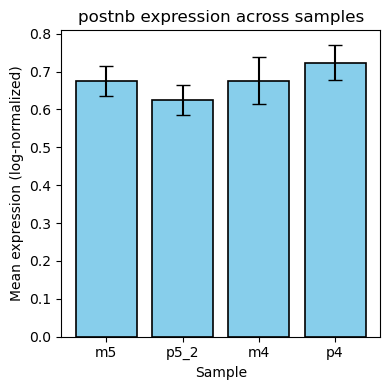

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem  # standard error of the mean

# --- Parameters ---
adata = adata_subset  # assuming this is your subset

# Convert to dense dataframe
# Convert expression matrix to DataFrame
df = pd.DataFrame(adata.X.toarray(), columns=adata.var_names)
df["sample"] = adata.obs["sample"].values

# Loop through genes
for gene in genes:
    # Compute mean and SE per sample
    plot_df = (
        df.groupby("sample")[gene]
        .agg(mean="mean", se=sem)
        .reindex(samples)  # maintain order
        .reset_index()
    )
    # Plot using matplotlib
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(plot_df["sample"], plot_df["mean"], yerr=plot_df["se"],
           capsize=5, color="skyblue", edgecolor="black", linewidth=1.2)

    ax.set_ylabel("Mean expression (log-normalized)")
    ax.set_xlabel("Sample")
    ax.set_title(f"{gene} expression across samples")
    ax.set_ylim(bottom=0)  # avoid negative y-axis
    plt.tight_layout()
    plt.savefig(f"{gene}_barplot_by_sample.pdf", dpi=300)
    plt.show()